In [5]:
import sys
import os
import pandas as pd
import getpass
import torch

from google.colab import userdata
openai_key = userdata.get('OPENROUTER_API_KEY')

In [6]:
!pip -q install backoff

In [7]:
!git clone https://github.com/bencejdanko/bert-tweeteval

sys.path.append(os.path.abspath('/content/bert-tweeteval/src'))

from download import download_and_split_dataset
from llm_eval import LLMEvaluator, PROMPT_1_MINIMAL, PROMPT_2_STRUCTURED, LABELS

Cloning into 'bert-tweeteval'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 206 (delta 131), reused 115 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (206/206), 794.59 KiB | 4.29 MiB/s, done.
Resolving deltas: 100% (131/131), done.


In [8]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Test set size: {len(test_df)}")

README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Test set size: 1421


In [9]:
evaluator_qwen = LLMEvaluator(hf_model_name="Qwen/Qwen3-4B-Instruct-2507")
evaluator_qwen.load_hf_model()

Loading HF model: Qwen/Qwen3-4B-Instruct-2507 on cuda...


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

In [10]:
res_qwen_p1 = evaluator_qwen.evaluate(test_df, "hf", PROMPT_1_MINIMAL)


Evaluating hf (Batch size 100):   0%|          | 0/15 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Evaluating hf (Batch size 100): 100%|██████████| 15/15 [00:35<00:00,  2.35s/it]


In [11]:
res_qwen_p2 = evaluator_qwen.evaluate(test_df, "hf", PROMPT_2_STRUCTURED)


Evaluating hf (Batch size 100): 100%|██████████| 15/15 [01:09<00:00,  4.61s/it]


In [12]:
evaluator_openai = LLMEvaluator(openai_api_key=openai_key)

In [13]:
res_gpt_p1 = evaluator_openai.evaluate(test_df, "openai", PROMPT_1_MINIMAL)


Evaluating openai (Batch size 100): 100%|██████████| 15/15 [01:10<00:00,  4.70s/it]


In [14]:
res_gpt_p2 = evaluator_openai.evaluate(test_df, "openai", PROMPT_2_STRUCTURED)


Evaluating openai (Batch size 100): 100%|██████████| 15/15 [00:53<00:00,  3.57s/it]


In [15]:
results = {
    "GPT-4o-mini (Minimal)": res_gpt_p1,
    "GPT-4o-mini (Structured)": res_gpt_p2,
    "Qwen3-4B-Instruct-2507 (Minimal)": res_qwen_p1,
    "Qwen3-4B-Instruct-2507 (Structured)": res_qwen_p2
}

comparison_df = pd.DataFrame({
    k: {m: v[m] for m in ["Accuracy", "Macro-F1", "Time_per_100"]}
    for k, v in results.items()
}).transpose()

comparison_df

,Accuracy,Macro-F1,Time_per_100
GPT-4o-mini (Minimal),0.800141,0.601466,5060.112734
GPT-4o-mini (Structured),0.821956,0.781499,3823.308211
Qwen3-4B-Instruct-2507 (Minimal),0.751583,0.584864,2571.471757
Qwen3-4B-Instruct-2507 (Structured),0.812104,0.758003,4931.231370


In [16]:
comparison_df.to_markdown()

'|                                     |   Accuracy |   Macro-F1 |   Time_per_100 |\n|:------------------------------------|-----------:|-----------:|---------------:|\n| GPT-4o-mini (Minimal)               |   0.800141 |   0.601466 |        5060.11 |\n| GPT-4o-mini (Structured)            |   0.821956 |   0.781499 |        3823.31 |\n| Qwen3-4B-Instruct-2507 (Minimal)    |   0.751583 |   0.584864 |        2571.47 |\n| Qwen3-4B-Instruct-2507 (Structured) |   0.812104 |   0.758003 |        4931.23 |'

In [17]:
from datasets import Dataset
import huggingface_hub

hf_token = userdata.get('HF_TOKEN')
huggingface_hub.login(token=hf_token)

predictions_data = {
    'True_Labels': results["GPT-4o-mini (Minimal)"]["True_Labels"]
}
for k, v in results.items():
    predictions_data[k] = v["Predictions"]

predictions_dataset = Dataset.from_dict(predictions_data)
predictions_dataset.push_to_hub('bdanko/tweeteval-llm-evaluation-predictions')

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 5.99kB / 5.99kB            

CommitInfo(commit_url='https://huggingface.co/datasets/bdanko/tweeteval-llm-evaluation-predictions/commit/da1e6c575ae766cdb7f2dc7262d4287684689038', commit_message='Upload dataset', commit_description='', oid='da1e6c575ae766cdb7f2dc7262d4287684689038', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/bdanko/tweeteval-llm-evaluation-predictions', endpoint='https://huggingface.co', repo_type='dataset', repo_id='bdanko/tweeteval-llm-evaluation-predictions'), pr_revision=None, pr_num=None)

In [18]:
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score

ds = load_dataset("bdanko/tweeteval-llm-evaluation-predictions", split="train")

model_names = [
    "GPT-4o-mini (Minimal)",
    "GPT-4o-mini (Structured)",
    "Qwen3-4B-Instruct-2507 (Minimal)",
    "Qwen3-4B-Instruct-2507 (Structured)",
]

results = {}
for name in model_names:
    y_true = ds["True_Labels"]
    y_pred = ds[name]
    results[name] = {
        "True_Labels":  y_true,
        "Predictions":  y_pred,
        "Accuracy":     accuracy_score(y_true, y_pred),
        "Macro-F1":     f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Time_per_100": None,  # not stored — would need re-inference to recover
    }


README.md:   0%|          | 0.00/502 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.99k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1421 [00:00<?, ? examples/s]

In [19]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

extended_rows = {}
for name, res in results.items():
    y_true = res['True_Labels']
    y_pred = res['Predictions']
    extended_rows[name] = {
        'Accuracy':        res['Accuracy'],
        'Macro-F1':        res['Macro-F1'],
        'Macro-Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro-Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Time_per_100':    res['Time_per_100'],
    }

extended_df = pd.DataFrame(extended_rows).transpose()
print(extended_df.to_markdown())
extended_df


|                                     |   Accuracy |   Macro-F1 |   Macro-Precision |   Macro-Recall |   Time_per_100 |
|:------------------------------------|-----------:|-----------:|------------------:|---------------:|---------------:|
| GPT-4o-mini (Minimal)               |   0.800141 |   0.601466 |          0.653766 |       0.579754 |            nan |
| GPT-4o-mini (Structured)            |   0.821956 |   0.781499 |          0.791218 |       0.773544 |            nan |
| Qwen3-4B-Instruct-2507 (Minimal)    |   0.751583 |   0.584864 |          0.594974 |       0.581751 |            nan |
| Qwen3-4B-Instruct-2507 (Structured) |   0.812104 |   0.758003 |          0.793805 |       0.741873 |            nan |


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,Time_per_100
GPT-4o-mini (Minimal),0.800141,0.601466,0.653766,0.579754,NaN
GPT-4o-mini (Structured),0.821956,0.781499,0.791218,0.773544,NaN
Qwen3-4B-Instruct-2507 (Minimal),0.751583,0.584864,0.594974,0.581751,NaN
Qwen3-4B-Instruct-2507 (Structured),0.812104,0.758003,0.793805,0.741873,NaN


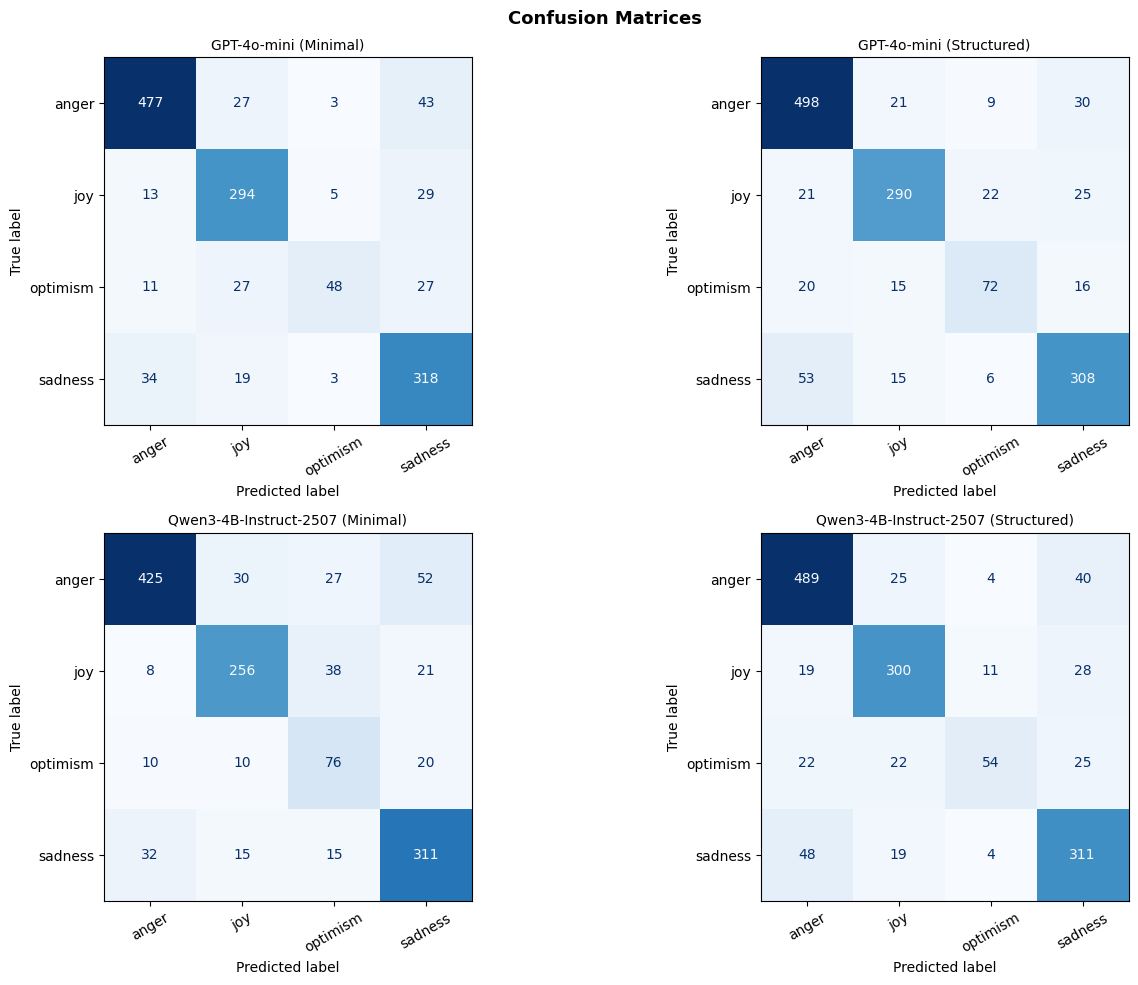

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_names = ['anger', 'joy', 'optimism', 'sadness']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['True_Labels'], res['Predictions'], labels=label_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', labelrotation=30)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
